In [2]:
# PROJECT: Supply Chain Demand Forecasting & Process Analysis
# PHASE 3: Demand Forecasting with Facebook Prophet


# Install Prophet
!pip install prophet -q
!pip install kaggle -q

import os, json

kaggle_credentials = {
    "username": "cynthiawanjiku",
    "key": "KGAT_8230434584795821c21884683601bd65"
}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d shashwatwork/dataco-smart-supply-chain-for-big-data-analysis --unzip -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin-1')
print(f"✅ Dataset loaded — {df.shape[0]:,} rows")
print("✅ Prophet installed and ready")

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis
License(s): CC0-1.0
✅ Dataset loaded — 180,519 rows
✅ Prophet installed and ready


In [3]:
# Prepare monthly time series data for forecasting


# Parse dates
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'],
                                   errors='coerce')

# Use only pre-shock data (Jan 2015 - Sep 2017)
# Oct 2017 onwards excluded because the demand shock
# was an external event, not a natural trend
df_clean = df[df['order_date'] < '2017-10-01'].copy()

# Aggregate to monthly order volume
monthly = df_clean.groupby(pd.Grouper(key='order_date', freq='M')).agg(
    order_count=('Order Id', 'count'),
    total_sales=('Sales', 'sum')
).reset_index()

monthly.columns = ['ds', 'y', 'total_sales']

print(f" Monthly data prepared — {len(monthly)} months of data")
print(f" Date range: {monthly['ds'].min().strftime('%b %Y')} to {monthly['ds'].max().strftime('%b %Y')}")
print(f" Avg monthly orders: {monthly['y'].mean():,.0f}")
print(f" Min monthly orders: {monthly['y'].min():,.0f}")
print(f" Max monthly orders: {monthly['y'].max():,.0f}")
print("\n Monthly data preview:")
print(monthly.head(10))

 Monthly data prepared — 33 months of data
 Date range: Jan 2015 to Sep 2017
 Avg monthly orders: 5,211
 Min monthly orders: 4,729
 Max monthly orders: 5,398

 Monthly data preview:
          ds     y   total_sales
0 2015-01-31  5322  1.051590e+06
1 2015-02-28  4729  9.270099e+05
2 2015-03-31  5362  1.051254e+06
3 2015-04-30  5126  1.014463e+06
4 2015-05-31  5357  1.050478e+06
5 2015-06-30  5134  1.024006e+06
6 2015-07-31  5299  1.038081e+06
7 2015-08-31  5273  1.029495e+06
8 2015-09-30  5140  1.018339e+06
9 2015-10-31  5302  1.049154e+06


In [4]:
# Build and train the Prophet forecast model


# Initialize Prophet model
# yearly_seasonality=True captures annual patterns
# weekly_seasonality=False because we're using monthly data
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    interval_width=0.95  # 95% confidence interval
)

# Train the model on historical data
model.fit(monthly[['ds', 'y']])

# Create future dataframe — forecast 6 months ahead
# (Oct 2017 through Mar 2018)
future = model.make_future_dataframe(periods=6, freq='M')

# Generate forecast
forecast = model.predict(future)

print(" Model trained successfully!")
print(f" Forecast covers: {forecast['ds'].iloc[-6].strftime('%b %Y')} to {forecast['ds'].iloc[-1].strftime('%b %Y')}")
print("\n Forecasted monthly orders (next 6 months):")

future_only = forecast.tail(6)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
future_only.columns = ['Month', 'Forecast', 'Lower Bound', 'Upper Bound']
future_only['Month'] = future_only['Month'].dt.strftime('%b %Y')
future_only['Forecast'] = future_only['Forecast'].round(0).astype(int)
future_only['Lower Bound'] = future_only['Lower Bound'].round(0).astype(int)
future_only['Upper Bound'] = future_only['Upper Bound'].round(0).astype(int)
print(future_only.to_string(index=False))

 Model trained successfully!
 Forecast covers: Oct 2017 to Mar 2018

 Forecasted monthly orders (next 6 months):
   Month  Forecast  Lower Bound  Upper Bound
Oct 2017      5355         5310         5402
Nov 2017      5203         5152         5256
Dec 2017      5283         5231         5337
Jan 2018      5228         5176         5282
Feb 2018      4758         4704         4811
Mar 2018      5287         5236         5342


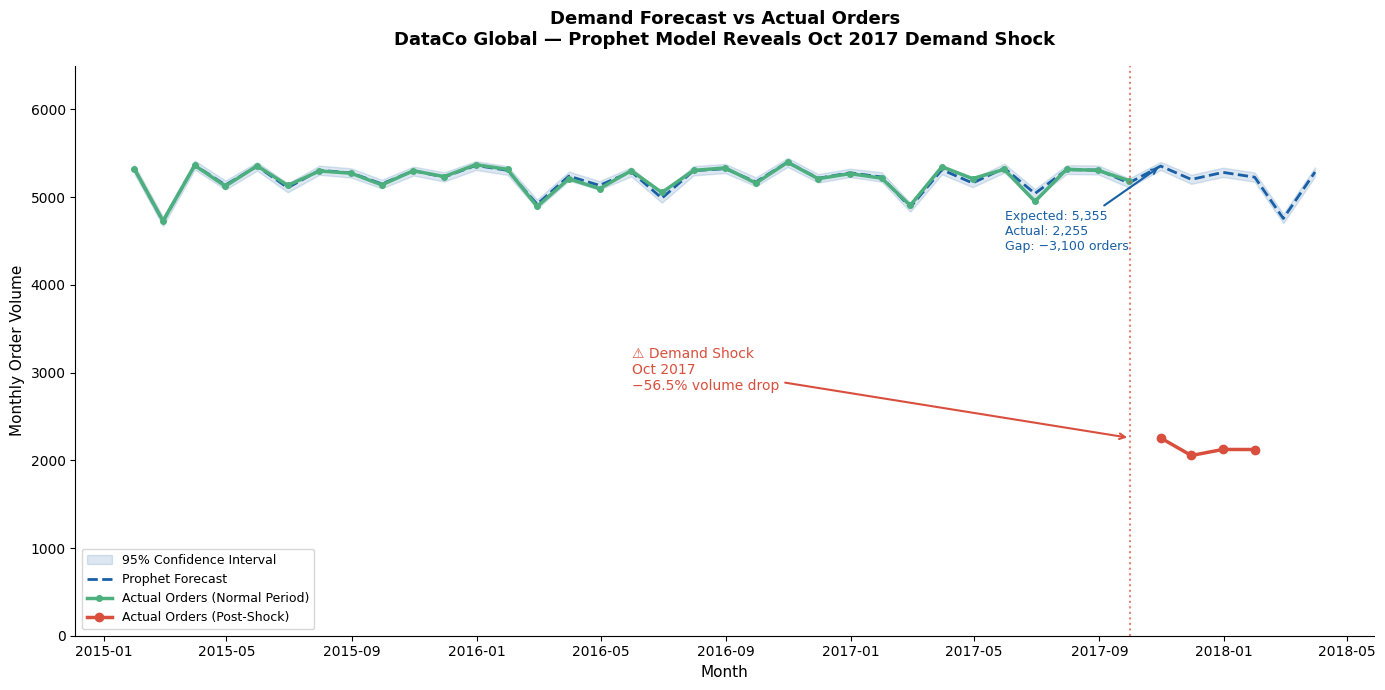

Chart saved as chart_04_forecast_vs_actual.png


In [6]:
# Forecast vs Actual — The Demand Gap Chart


# Actual data including the shock period
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')

actual_full = df.groupby(pd.Grouper(key='order_date', freq='M')).agg(
    order_count=('Order Id', 'count')
).reset_index()
actual_full.columns = ['ds', 'actual']

# Merge forecast with actual
comparison = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(
    actual_full, on='ds', how='left'
)

# Split into pre-shock and shock periods
pre_shock = comparison[comparison['ds'] < '2017-10-01']
shock = comparison[comparison['ds'] >= '2017-10-01']

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Confidence interval band
ax.fill_between(comparison['ds'],
                comparison['yhat_lower'],
                comparison['yhat_upper'],
                alpha=0.15, color='#185FA5', label='95% Confidence Interval')

# Forecast line (full period)
ax.plot(comparison['ds'], comparison['yhat'],
        color='#185FA5', linewidth=2, linestyle='--', label='Prophet Forecast')

# Actual orders - pre shock (green)
ax.plot(pre_shock['ds'], pre_shock['actual'],
        color='#4caf7d', linewidth=2.5, marker='o',
        markersize=4, label='Actual Orders (Normal Period)')

# Actual orders — shock period (red)
ax.plot(shock['ds'], shock['actual'],
        color='#d94f3d', linewidth=2.5, marker='o',
        markersize=6, label='Actual Orders (Post-Shock)')

# Shock annotation
ax.axvline(x=pd.Timestamp('2017-10-01'), color='#d94f3d',
           linewidth=1.5, linestyle=':', alpha=0.7)
ax.annotate('⚠ Demand Shock\nOct 2017\n−56.5% volume drop',
            xy=(pd.Timestamp('2017-10-01'), 2255),
            xytext=(pd.Timestamp('2016-06-01'), 2800),
            fontsize=10, color='#d94f3d',
            arrowprops=dict(arrowstyle='->', color='#d94f3d', lw=1.5))

# Gap annotation
ax.annotate('Expected: 5,355\nActual: 2,255\nGap: −3,100 orders',
            xy=(pd.Timestamp('2017-10-31'), 5355),
            xytext=(pd.Timestamp('2017-06-01'), 4400),
            fontsize=9, color='#185FA5',
            arrowprops=dict(arrowstyle='->', color='#185FA5', lw=1.5))

ax.set_title('Demand Forecast vs Actual Orders\nDataCo Global — Prophet Model Reveals Oct 2017 Demand Shock',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Monthly Order Volume', fontsize=11)
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim(0, 6500)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart_04_forecast_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as chart_04_forecast_vs_actual.png")

**Revenue Impact of the Demand Shock**

Revenue Impact of October 2017 Demand Shock:
  Oct 2017: Expected $   1,037,826 | Actual $   1,073,994 | Gap $     -36,168
  Nov 2017: Expected $   1,037,826 | Actual $     626,914 | Gap $     410,912
  Dec 2017: Expected $   1,037,826 | Actual $     503,911 | Gap $     533,915
  Jan 2018: Expected $   1,037,826 | Actual $     331,650 | Gap $     706,176
  TOTAL REVENUE GAP (Oct 2017 – Jan 2018): $1,614,835


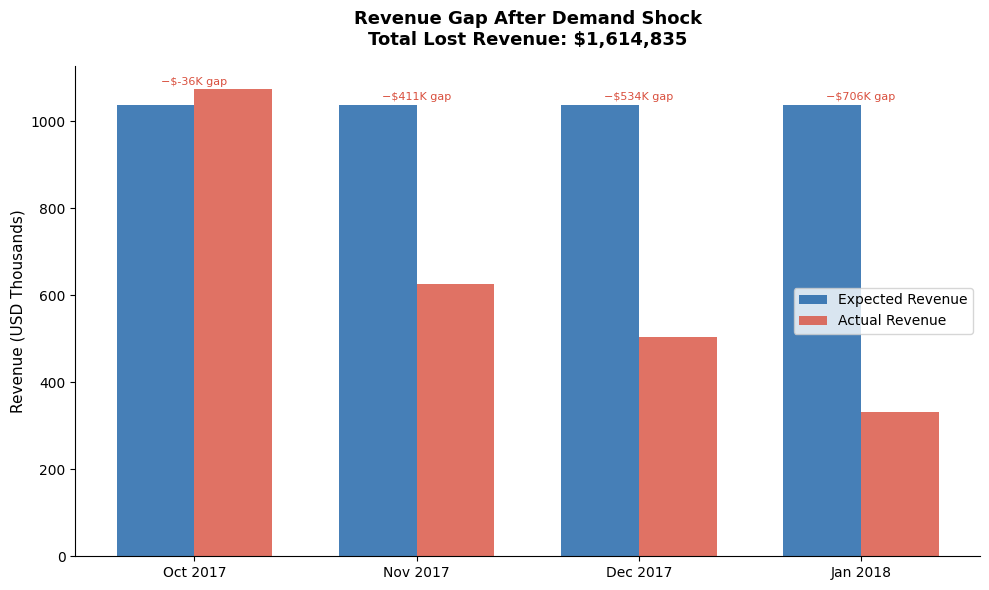


 Chart saved as chart_05_revenue_gap.png


In [7]:
# Revenue Impact of the Demand Shock


# Calculate expected vs actual revenue post-shock
actual_sales = df.groupby(pd.Grouper(key='order_date', freq='M')).agg(
    actual_sales=('Sales', 'sum')
).reset_index()
actual_sales.columns = ['ds', 'actual_sales']

# Average monthly sales from normal period
avg_monthly_sales = df[df['order_date'] < '2017-10-01']['Sales'].sum() / 33

# Merge with forecast
revenue_comparison = forecast[['ds', 'yhat']].merge(
    actual_sales, on='ds', how='left'
)

# Post shock only
post_shock = revenue_comparison[revenue_comparison['ds'] >= '2017-10-01'].copy()
post_shock['expected_sales'] = avg_monthly_sales
post_shock['revenue_gap'] = post_shock['expected_sales'] - post_shock['actual_sales']
post_shock['month'] = post_shock['ds'].dt.strftime('%b %Y')

total_gap = post_shock['revenue_gap'].sum()

print("Revenue Impact of October 2017 Demand Shock:")
print("=" * 55)
for _, row in post_shock.iterrows():
    if pd.notna(row['actual_sales']):
        print(f"  {row['month']}: Expected ${row['expected_sales']:>12,.0f} | "
              f"Actual ${row['actual_sales']:>12,.0f} | "
              f"Gap ${row['revenue_gap']:>12,.0f}")

print("=" * 55)
print(f"  TOTAL REVENUE GAP (Oct 2017 – Jan 2018): ${total_gap:,.0f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

post_shock_clean = post_shock[post_shock['actual_sales'].notna()]

x = range(len(post_shock_clean))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x],
               post_shock_clean['expected_sales'] / 1000,
               width, color='#185FA5', alpha=0.8, label='Expected Revenue')
bars2 = ax.bar([i + width/2 for i in x],
               post_shock_clean['actual_sales'] / 1000,
               width, color='#d94f3d', alpha=0.8, label='Actual Revenue')

ax.set_xticks(list(x))
ax.set_xticklabels(post_shock_clean['month'], fontsize=10)
ax.set_ylabel('Revenue (USD Thousands)', fontsize=11)
ax.set_title(f'Revenue Gap After Demand Shock\nTotal Lost Revenue: ${total_gap:,.0f}',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add gap labels on top of each pair
for i, (_, row) in enumerate(post_shock_clean.iterrows()):
    if pd.notna(row['actual_sales']):
        gap = row['revenue_gap'] / 1000
        ax.text(i, max(row['expected_sales'], row['actual_sales']) / 1000 + 10,
                f'−${gap:,.0f}K gap',
                ha='center', fontsize=8, color='#d94f3d', fontweight='500')

plt.tight_layout()
plt.savefig('chart_05_revenue_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n Chart saved as chart_05_revenue_gap.png")

In [8]:
# download all charts

from google.colab import files

files.download('chart_04_forecast_vs_actual.png')
files.download('chart_05_revenue_gap.png')

print("Both charts downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Both charts downloaded
